<a href="https://colab.research.google.com/github/adv-11/Deepfake-Classification-DeepLearning/blob/main/Deepfake_Detector_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Deepfake Detector — Baseline CNN Training

Binary classifier (**REAL** vs **FAKE**) using transfer-learned CNNs on two datasets:

| Dataset | Resolution | Description |
|---|---|---|
| **CIFAKE** | 32×32 | 120K images — CIFAR-10 real + Stable Diffusion fake |
| **DeepDetect-2025** | 256×256+ | Real vs AI-generated using recent diffusion models |

**Models:** ResNet-18 · ResNet-50 · EfficientNet-B0

> **Runtime → Change runtime type → T4 GPU** before running.

---
## 1 · Setup & Installs

In [1]:
!pip install -q timm scikit-learn matplotlib tqdm

In [2]:
import os, json, time, copy
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split
from torchvision import datasets, transforms, models
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
)
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")

Device: cuda
GPU:    NVIDIA A100-SXM4-40GB


---
## 2 · Download & Prepare Datasets

### Option A — CIFAKE from Kaggle
Upload your `kaggle.json` when prompted, then run the cell below.  
*(If you already have the data in Drive, skip to Option C.)*

In [3]:
# --- Kaggle credentials ---
from google.colab import files
print("Upload your kaggle.json:")
uploaded = files.upload()
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Upload your kaggle.json:


Saving cifake.zip to cifake.zip
mv: cannot stat 'kaggle.json': No such file or directory


In [4]:
# --- Download CIFAKE ---
!pip install -q kaggle
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images -p /content/data --unzip

CIFAKE_ROOT = "/content/data"  # should contain train/ and test/ with REAL/ FAKE/ subdirs
print("\nCIFAKE layout:")
!find {CIFAKE_ROOT} -maxdepth 3 -type d | head -20

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 173MB/s]


CIFAKE layout:
/content/data
/content/data/train
/content/data/train/REAL
/content/data/train/FAKE
/content/data/test
/content/data/test/REAL
/content/data/test/FAKE


### Option B — DeepDetect-2025

Replace the path below with wherever your DeepDetect-2025 data lives.  
Expected layout: `train/{real,fake}/` and `test/{real,fake}/`

In [5]:
# --- Adjust this path to your DeepDetect-2025 data ---
DEEPDETECT_ROOT = "/content/data/deepdetect2025"  # <-- CHANGE ME

# If mounting from Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# DEEPDETECT_ROOT = "/content/drive/MyDrive/deepdetect2025"

### Option C — Mount from Google Drive
If both datasets are in your Drive, mount and point the paths.

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')
# CIFAKE_ROOT     = "/content/drive/MyDrive/datasets/cifake"
# DEEPDETECT_ROOT = "/content/drive/MyDrive/datasets/deepdetect2025"

---
## 3 · Configuration

In [7]:
# ╔══════════════════════════════════════════════╗
# ║          EDIT THESE SETTINGS                 ║
# ╚══════════════════════════════════════════════╝

CFG = {
    # Which dataset to train on: "cifake" | "deepdetect" | "both"
    "dataset":       "cifake",

    # Which model: "resnet18" | "resnet50" | "efficientnet"
    "model":         "resnet18",

    # Use ImageNet pretrained weights?
    "pretrained":    True,

    # Training hyperparameters
    "epochs":        30,
    "batch_size":    64,
    "lr":            1e-3,
    "weight_decay":  1e-4,
    "scheduler":     "cosine",   # "cosine" | "step"
    "step_size":     10,
    "gamma":         0.1,
    "patience":      7,          # early stopping patience

    # Data
    "img_size":      224,
    "val_split":     0.10,
    "num_workers":   2,
    "seed":          42,

    # Paths (set in section 2 above)
    "cifake_root":     CIFAKE_ROOT,
    "deepdetect_root": DEEPDETECT_ROOT,
    "output_dir":      "/content/runs",
}

torch.manual_seed(CFG["seed"])
print("Config ready.")
for k, v in CFG.items():
    print(f"  {k:18s} = {v}")

Config ready.
  dataset            = cifake
  model              = resnet18
  pretrained         = True
  epochs             = 30
  batch_size         = 64
  lr                 = 0.001
  weight_decay       = 0.0001
  scheduler          = cosine
  step_size          = 10
  gamma              = 0.1
  patience           = 7
  img_size           = 224
  val_split          = 0.1
  num_workers        = 2
  seed               = 42
  cifake_root        = /content/data
  deepdetect_root    = /content/data/deepdetect2025
  output_dir         = /content/runs


---
## 4 · Data Loading

In [8]:
def get_transforms(img_size, is_train):
    """Training augmentations / eval normalization."""
    if is_train:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.2, hue=0.05),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.1),
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])


def load_single_dataset(name, cfg):
    """Load one dataset → (train_loader, val_loader, test_loader)."""
    root = cfg["cifake_root"] if name == "cifake" else cfg["deepdetect_root"]
    sz   = cfg["img_size"]

    train_full = datasets.ImageFolder(os.path.join(root, "train"),
                                      transform=get_transforms(sz, True))
    test_ds    = datasets.ImageFolder(os.path.join(root, "test"),
                                      transform=get_transforms(sz, False))

    print(f"  [{name}] classes → idx: {train_full.class_to_idx}")

    # Ensure 0 = real, 1 = fake
    cls = train_full.class_to_idx
    real_keys = [k for k in cls if k.lower() in ("real", "0")]
    fake_keys = [k for k in cls if k.lower() in ("fake", "1")]
    if real_keys and fake_keys and cls[real_keys[0]] > cls[fake_keys[0]]:
        print("  ⚠  Swapping indices so 0=real, 1=fake")
        for ds in (train_full, test_ds):
            ds.samples = [(p, 1 - y) for p, y in ds.samples]
            ds.targets = [1 - y for y in ds.targets]

    # Train / val split
    n_val   = int(len(train_full) * cfg["val_split"])
    n_train = len(train_full) - n_val
    gen = torch.Generator().manual_seed(cfg["seed"])
    train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=gen)

    # Eval transform for val split
    val_ds.dataset = copy.copy(train_full)
    val_ds.dataset.transform = get_transforms(sz, False)

    kw = dict(batch_size=cfg["batch_size"], num_workers=cfg["num_workers"],
              pin_memory=True)
    train_loader = DataLoader(train_ds, shuffle=True,  drop_last=True, **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

    print(f"  [{name}] train={n_train}  val={n_val}  test={len(test_ds)}")
    return train_loader, val_loader, test_loader


def load_combined(cfg):
    """Merge CIFAKE + DeepDetect-2025."""
    sz = cfg["img_size"]
    all_train, all_test = [], []
    for name, key in [("cifake", "cifake_root"), ("deepdetect", "deepdetect_root")]:
        root = cfg[key]
        tr = datasets.ImageFolder(os.path.join(root, "train"),
                                   transform=get_transforms(sz, True))
        te = datasets.ImageFolder(os.path.join(root, "test"),
                                   transform=get_transforms(sz, False))
        print(f"  [{name}] classes: {tr.class_to_idx}  "
              f"train={len(tr)}  test={len(te)}")
        all_train.append(tr)
        all_test.append(te)

    train_full = ConcatDataset(all_train)
    test_ds    = ConcatDataset(all_test)

    n_val   = int(len(train_full) * cfg["val_split"])
    n_train = len(train_full) - n_val
    gen = torch.Generator().manual_seed(cfg["seed"])
    train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=gen)

    kw = dict(batch_size=cfg["batch_size"], num_workers=cfg["num_workers"],
              pin_memory=True)
    train_loader = DataLoader(train_ds, shuffle=True,  drop_last=True, **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

    print(f"  [combined] train={n_train}  val={n_val}  test={len(test_ds)}")
    return train_loader, val_loader, test_loader

print("Data functions ready.")

Data functions ready.


In [9]:
# ---- Load the dataset(s) ----
print(f"Loading dataset: {CFG['dataset']}\n")
if CFG["dataset"] == "both":
    train_loader, val_loader, test_loader = load_combined(CFG)
else:
    train_loader, val_loader, test_loader = load_single_dataset(CFG["dataset"], CFG)

Loading dataset: cifake

  [cifake] classes → idx: {'FAKE': 0, 'REAL': 1}
  ⚠  Swapping indices so 0=real, 1=fake
  [cifake] train=90000  val=10000  test=20000


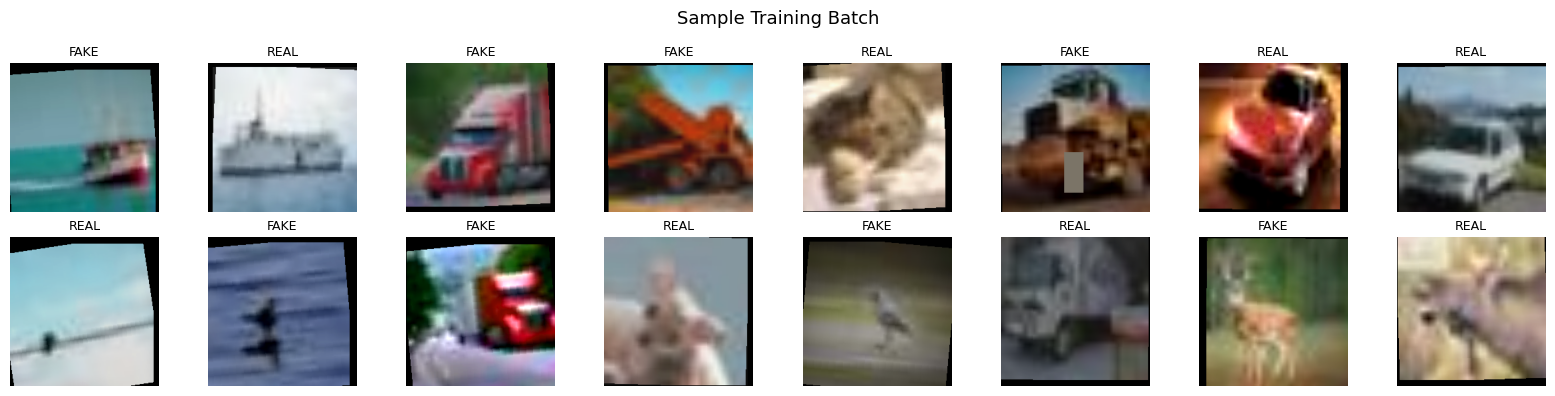

In [10]:
# ---- Preview a batch ----
imgs, labels = next(iter(train_loader))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = imgs[i] * std + mean
    ax.imshow(img.permute(1,2,0).clamp(0,1).numpy())
    ax.set_title("REAL" if labels[i] == 0 else "FAKE", fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Training Batch", fontsize=13)
plt.tight_layout()
plt.show()

---
## 5 · Model

In [11]:
def build_model(name, pretrained=True):
    """Binary classifier: single logit output → BCEWithLogitsLoss."""
    if name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(model.fc.in_features, 1),
        )
    elif name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.fc.in_features, 1),
        )
    elif name == "efficientnet":
        model = timm.create_model(
            "efficientnet_b0", pretrained=pretrained,
            num_classes=1, drop_rate=0.3,
        )
    else:
        raise ValueError(f"Unknown model: {name}")
    return model


model = build_model(CFG["model"], CFG["pretrained"]).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {CFG['model']}")
print(f"  Total params:     {total_params:>12,}")
print(f"  Trainable params: {train_params:>12,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


Model: resnet18
  Total params:       11,177,025
  Trainable params:   11,177,025


---
## 6 · Training Loop

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds    = (torch.sigmoid(logits) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total   += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []
    for imgs, labels in tqdm(loader, desc="Eval ", leave=False):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        logits = model(imgs).squeeze(1)
        loss   = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        all_probs.append(torch.sigmoid(logits).cpu())
        all_labels.append(labels.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_probs  = torch.cat(all_probs).numpy()
    all_preds  = (all_probs >= 0.5).astype(int)

    metrics = {
        "loss":      running_loss / len(all_labels),
        "accuracy":  accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall":    recall_score(all_labels, all_preds, zero_division=0),
        "f1":        f1_score(all_labels, all_preds, zero_division=0),
        "auc_roc":   roc_auc_score(all_labels, all_probs),
    }
    return metrics, all_labels, all_preds, all_probs

print("Training functions ready.")

Training functions ready.


In [13]:
# ---- Optimizer & scheduler ----
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=CFG["lr"],
                        weight_decay=CFG["weight_decay"])

if CFG["scheduler"] == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
else:
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=CFG["step_size"],
                                          gamma=CFG["gamma"])

# ---- Output directory ----
tag = f"{CFG['model']}_{CFG['dataset']}_{datetime.now():%Y%m%d_%H%M%S}"
run_dir = Path(CFG["output_dir"]) / tag
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Outputs → {run_dir}")

Outputs → /content/runs/resnet18_cifake_20260414_030110


In [14]:
# ╔══════════════════════════════════════════════╗
# ║             TRAINING LOOP                    ║
# ╚══════════════════════════════════════════════╝

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_auc = 0.0
patience_ctr = 0

print(f"\n{'='*65}")
print(f"  Training {CFG['model']} on {CFG['dataset']} for {CFG['epochs']} epochs")
print(f"  bs={CFG['batch_size']}  lr={CFG['lr']}  img={CFG['img_size']}  device={device}")
print(f"{'='*65}\n")

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device)
    val_metrics, _, _, _ = evaluate(
        model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])

    lr_now  = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0

    print(f"Epoch {epoch:3d}/{CFG['epochs']}  "
          f"train_loss={train_loss:.4f}  acc={train_acc:.4f}  │  "
          f"val_loss={val_metrics['loss']:.4f}  acc={val_metrics['accuracy']:.4f}  "
          f"auc={val_metrics['auc_roc']:.4f}  "
          f"lr={lr_now:.2e}  ({elapsed:.1f}s)")

    # Checkpoint best
    if val_metrics["auc_roc"] > best_val_auc:
        best_val_auc = val_metrics["auc_roc"]
        patience_ctr = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_auc": best_val_auc,
            "cfg": CFG,
        }, run_dir / "best_model.pt")
        print(f"         ✓ New best val AUC = {best_val_auc:.4f} — saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= CFG["patience"]:
            print(f"\n⏹  Early stopping at epoch {epoch} "
                  f"(patience={CFG['patience']})")
            break

print(f"\nTraining complete. Best val AUC = {best_val_auc:.4f}")


  Training resnet18 on cifake for 30 epochs
  bs=64  lr=0.001  img=224  device=cuda



Train:   0%|          | 0/1406 [00:00<?, ?it/s]

Eval :   0%|          | 0/157 [00:00<?, ?it/s]

Epoch   1/30  train_loss=0.2275  acc=0.9080  │  val_loss=0.1771  acc=0.9297  auc=0.9851  lr=9.97e-04  (347.5s)
         ✓ New best val AUC = 0.9851 — saved.


Train:   0%|          | 0/1406 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/157 [00:00<?, ?it/s]

Epoch  29/30  train_loss=0.0126  acc=0.9952  │  val_loss=0.0637  acc=0.9830  auc=0.9987  lr=2.74e-06  (349.6s)


Train:   0%|          | 0/1406 [00:00<?, ?it/s]

Eval :   0%|          | 0/157 [00:00<?, ?it/s]

Epoch  30/30  train_loss=0.0115  acc=0.9959  │  val_loss=0.0620  acc=0.9832  auc=0.9987  lr=0.00e+00  (348.7s)

Training complete. Best val AUC = 0.9987


---
## 7 · Learning Curves

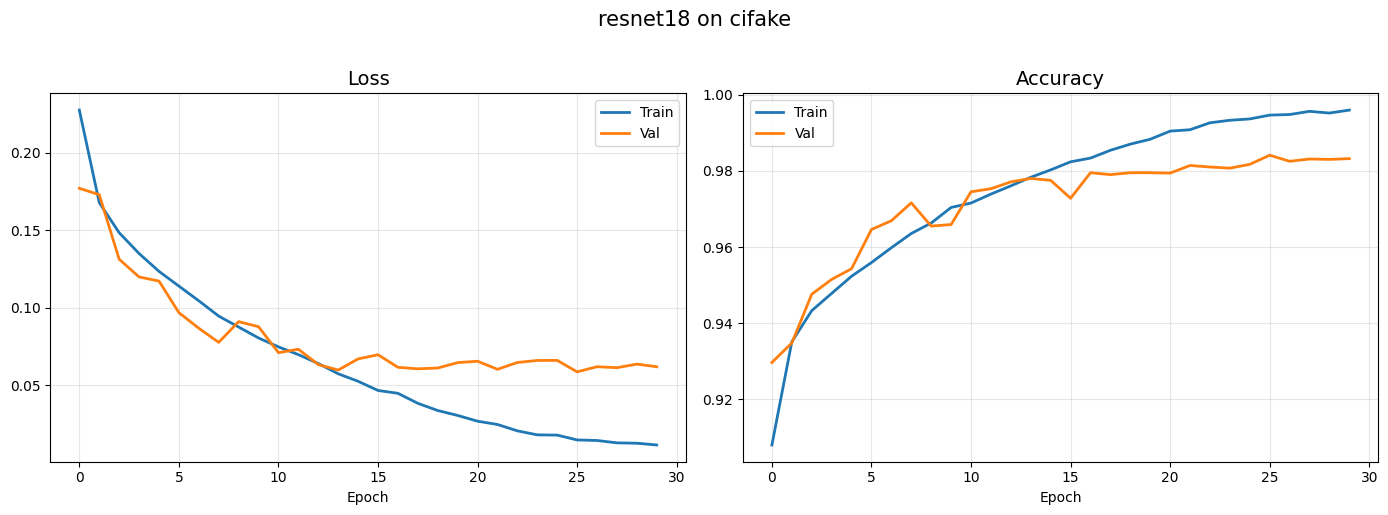

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0].plot(history["val_loss"],   label="Val",   linewidth=2)
axes[0].set_title("Loss", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="Train", linewidth=2)
axes[1].plot(history["val_acc"],   label="Val",   linewidth=2)
axes[1].set_title("Accuracy", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f"{CFG['model']} on {CFG['dataset']}", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(run_dir / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8 · Test-Set Evaluation

In [16]:
# Load best checkpoint
ckpt = torch.load(run_dir / "best_model.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']} (val AUC={ckpt['val_auc']:.4f})\n")

test_metrics, y_true, y_pred, y_prob = evaluate(
    model, test_loader, criterion, device)

print("=" * 50)
print("  TEST SET RESULTS")
print("=" * 50)
for k, v in test_metrics.items():
    print(f"    {k:12s}  {v:.4f}")

print()
print(classification_report(y_true, y_pred, target_names=["REAL", "FAKE"]))

Loaded best model from epoch 26 (val AUC=0.9987)



Eval :   0%|          | 0/313 [00:00<?, ?it/s]

  TEST SET RESULTS
    loss          0.0636
    accuracy      0.9825
    precision     0.9795
    recall        0.9856
    f1            0.9826
    auc_roc       0.9985

              precision    recall  f1-score   support

        REAL       0.99      0.98      0.98     10000
        FAKE       0.98      0.99      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



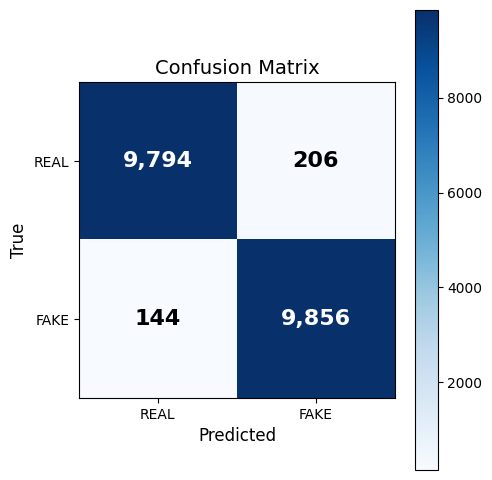

  TN =  9,794    FP =    206
  FN =    144    TP =  9,856


In [17]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
classes = ["REAL", "FAKE"]
ax.set_xticks(range(2)); ax.set_xticklabels(classes)
ax.set_yticks(range(2)); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix", fontsize=14)
for i in range(2):
    for j in range(2):
        color = "white" if cm[i][j] > cm.max()/2 else "black"
        ax.text(j, i, f"{cm[i][j]:,}", ha="center", va="center",
                color=color, fontsize=16, fontweight="bold")
fig.colorbar(im)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

print(f"  TN = {cm[0][0]:>6,}    FP = {cm[0][1]:>6,}")
print(f"  FN = {cm[1][0]:>6,}    TP = {cm[1][1]:>6,}")

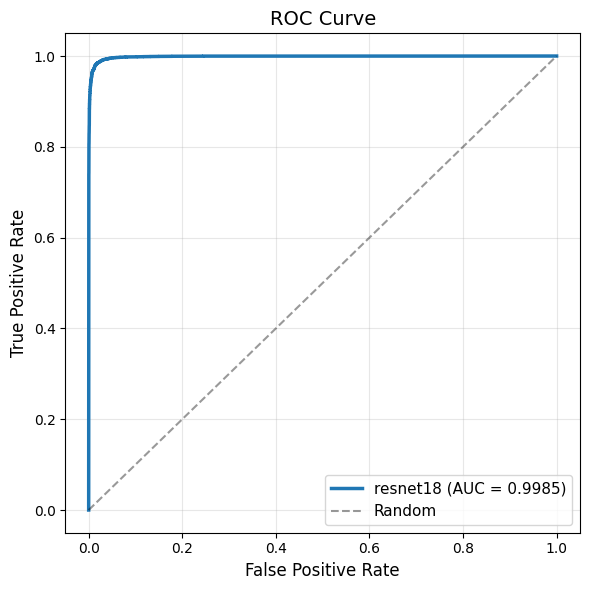

In [18]:
# ---- ROC Curve ----
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, linewidth=2.5,
        label=f"{CFG['model']} (AUC = {test_metrics['auc_roc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(run_dir / "roc_curve.png", dpi=150)
plt.show()

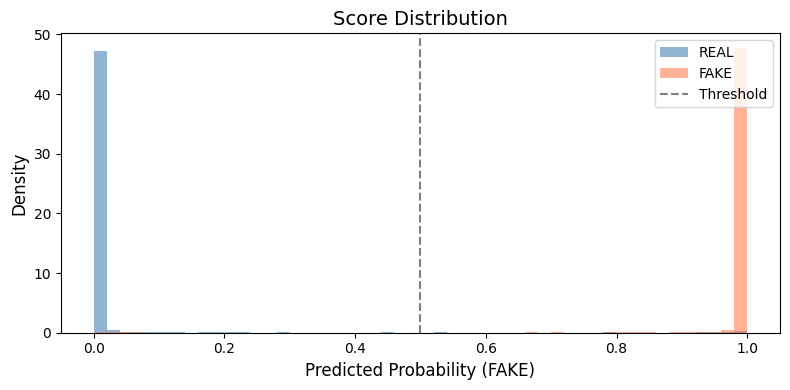

In [19]:
# ---- Prediction Distribution ----
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob[y_true == 0], bins=50, alpha=0.6, label="REAL",
        color="steelblue", density=True)
ax.hist(y_prob[y_true == 1], bins=50, alpha=0.6, label="FAKE",
        color="coral", density=True)
ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Threshold")
ax.set_xlabel("Predicted Probability (FAKE)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Score Distribution", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(run_dir / "score_distribution.png", dpi=150)
plt.show()

---
## 9 · Save Results & Export Model

In [20]:
# Save results JSON
results = {
    "model": CFG["model"],
    "dataset": CFG["dataset"],
    "pretrained": CFG["pretrained"],
    "best_epoch": ckpt["epoch"],
    "best_val_auc": best_val_auc,
    "test_metrics": test_metrics,
    "confusion_matrix": cm.tolist(),
    "config": CFG,
}
with open(run_dir / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"All outputs saved to: {run_dir}/")
!ls -lh {run_dir}

All outputs saved to: /content/runs/resnet18_cifake_20260414_030110/
total 129M
-rw-r--r-- 1 root root 129M Apr 14 05:32 best_model.pt
-rw-r--r-- 1 root root  34K Apr 14 05:55 confusion_matrix.png
-rw-r--r-- 1 root root  91K Apr 14 05:55 learning_curves.png
-rw-r--r-- 1 root root  900 Apr 14 05:55 results.json
-rw-r--r-- 1 root root  53K Apr 14 05:55 roc_curve.png
-rw-r--r-- 1 root root  33K Apr 14 05:55 score_distribution.png


In [21]:
# ---- Download the best model to your machine ----
from google.colab import files
files.download(str(run_dir / "best_model.pt"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 10 · Inference on New Images

Use this cell to classify individual images after training.

In [22]:
from PIL import Image

def predict_image(image_path, model, device, img_size=224):
    """Classify a single image as REAL or FAKE."""
    tf = get_transforms(img_size, is_train=False)
    img = Image.open(image_path).convert("RGB")
    tensor = tf(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logit = model(tensor).squeeze()
        prob  = torch.sigmoid(logit).item()

    label = "FAKE" if prob >= 0.5 else "REAL"
    confidence = prob if prob >= 0.5 else 1 - prob

    # Display
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(Image.open(image_path))
    color = "red" if label == "FAKE" else "green"
    ax.set_title(f"{label} ({confidence:.1%})", fontsize=14,
                 color=color, fontweight="bold")
    ax.axis("off")
    plt.show()

    return label, confidence


# --- Example: upload an image and classify ---
# uploaded = files.upload()
# for fname in uploaded:
#     predict_image(fname, model, device, CFG["img_size"])

print("predict_image() ready — upload an image to test.")

predict_image() ready — upload an image to test.
